# LSTM


LSTM(Long Short-Term Memory)은 **순환신경망(RNN, Recurrent Neural Network)** 의 일종으로, RNN의 단점인 **장기 의존성 문제** 를 해결하기 위해 고안된 신경망 구조이다.

**LSTM의 주요 특징**
1. **장기 의존성(Long-Term Dependency) 처리**
   - 일반적인 RNN은 시간이 길어질수록 과거의 정보를 잘 기억하지 못하는 **기울기 소멸(Gradient Vanishing)** 문제가 발생한다.
   - LSTM은 **Cell State**와 **게이트 구조**를 통해 중요한 정보를 장기적으로 유지할 수 있다.

2. **게이트(Gates) 구조**
   - LSTM은 정보를 선택적으로 기억하거나 잊게 해주는 3가지 게이트로 구성된다:
     - **입력 게이트(Input Gate):** 새로운 정보를 얼마나 저장할지 결정한다.
     - **망각 게이트(Forget Gate):** 기존 정보를 얼마나 잊을지 결정한다.
     - **출력 게이트(Output Gate):** 현재 상태를 출력에 얼마나 반영할지 결정한다.

3. **Cell State**
   - 네트워크의 **기억 장치** 역할을 하며, 중요하지 않은 정보는 제거하고 중요한 정보는 유지한다.


**LSTM의 구조**

![](https://d.pr/i/iPf2jG+)

아래는 LSTM의 한 타임스텝(time step)에서 이루어지는 연산 과정이다:

1. **망각 게이트 (Forget Gate)**  
    * 이전 상태 $h_{t-1}$와 입력 $x_t$를 통해 제거할 정보를 결정한다.

$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

2. **입력 게이트 (Input Gate)**
    - 입력 게이트 $i_t$와 새로운 정보 $\tilde{C}_t$를 결합하여 Cell State에 반영할 정보를 생성한다.
    
$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$

3. **Cell State 업데이트**  
    * 이전 Cell State $C_{t-1}$와 새로운 정보의 조합으로 현재 Cell State를 업데이트한다.

$$
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
$$

    

4. **출력 게이트 (Output Gate)**  
    * 출력 게이트 $o_t$와 업데이트된 Cell State $C_t$를 통해 새로운 은닉 상태 $h_t$를 계산한다.
    
$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t \cdot \tanh(C_t)
$$

**LSTM의 장점**

1. **장기 시퀀스 데이터 처리**: 시간의 흐름에 따라 발생하는 데이터를 잘 학습한다.
2. **텍스트, 음성, 시계열 데이터에 적합**: 언어 모델링, 번역, 주가 예측, 음성 인식 등 다양한 분야에서 활용된다.
3. **기울기 소멸 문제 해결**: Cell State와 게이트 구조 덕분에 학습이 안정적이다.

**추가 활용**

- **양방향 LSTM (Bidirectional LSTM)**: 양방향으로 데이터를 처리하여 더 많은 정보를 학습할 수 있다.
- **Stacked LSTM**: LSTM 레이어를 여러 층 쌓아 더 복잡한 패턴을 학습한다.

In [11]:
import torch
import torch.nn as nn

batch_size = 2
seq_len = 3 
input_size = 4
hidden_size = 5

x = torch.randn(batch_size,seq_len,input_size)
print('X.shape',x.shape)

lstm = nn.LSTM(input_size,hidden_size,batch_first=True)
output,(hidden,cell) = lstm(x)

print('output: ',output.shape)          # (batch_size, seq_len, hidden_size)
print('hidden: ',hidden.shape)          # (num_layer, batch_size, hidden_size)
print('cell: ',cell.shape)              # (num_layer, batch_size, hidden_size)


X.shape torch.Size([2, 3, 4])
output:  torch.Size([2, 3, 5])
hidden:  torch.Size([1, 2, 5])
cell:  torch.Size([1, 2, 5])


In [12]:
# keras 제공 imdb 데이터 셋
from tensorflow.keras.datasets import imdb

# 자주 사용되는 300개의 단어로 제한
vocab_size = 300

# 시퀀스 길이 제한
seq_len = 100

(X_train,y_train), (X_test,y_test) = imdb.load_data(num_words=vocab_size)

X_test = X_test[:10000]
y_test = y_test[:10000]


print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(25000,) (25000,)
(10000,) (10000,)


In [13]:
# 문장 길이 맞추기
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=seq_len, padding = 'post', truncating = 'post')
X_test = pad_sequences(X_test, maxlen=seq_len, padding = 'post', truncating = 'post')

In [14]:
# one-hot encoding
# X 입력값 (batch_size, seq_len, vocab_size)
from tensorflow.keras.utils import to_categorical

X_train_onehot = to_categorical(X_train,num_classes = vocab_size)
X_test_onehot = to_categorical(X_test,num_classes = vocab_size)
print(X_train_onehot.shape)
print(X_test_onehot.shape)

(25000, 100, 300)
(10000, 100, 300)


In [15]:
# tensor 변환
X_train_onehot = torch.tensor(X_train_onehot,dtype=torch.float)
X_test_onehot = torch.tensor(X_test_onehot,dtype=torch.float)

y_train = torch.tensor(y_train, dtype=torch.float).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float).unsqueeze(1)

print(X_train_onehot.shape, y_train.shape)
print(X_test_onehot.shape, y_test.shape)

torch.Size([25000, 100, 300]) torch.Size([25000, 1])
torch.Size([10000, 100, 300]) torch.Size([10000, 1])


## LSTM + ONEHOT ENCODING

In [16]:
# LSTM 모델 생성
class LSTMSentimenticNet(nn.Module):
    def __init__(self,input_dim,hidden_dim,output_dim):
        super().__init__()
        """
        Params:
        - input_size : 원핫 인코딩 기준 단어 수
        - hidden_size : LSTM 뉴런 수
        """
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim,output_dim)

    def forward(self, x):
        _, (hidden, cell)= self.lstm(x)
        output = self.fc(hidden[-1])        # (num_layer, batch_size, hidden_size)
        return output 
    
input_dim = vocab_size
hidden_size = 16
output_dim = 1

model=LSTMSentimenticNet(input_dim,hidden_size,output_dim)
model

LSTMSentimenticNet(
  (lstm): LSTM(300, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [17]:
# 모델 파라미터 확인
total_params = 0
for name, param in model.named_parameters():
    # print(name,param)
    if param.requires_grad:             # 미분 가능한 파라미터만
        param_count = param.numel()     # 모든 가중치 개수
        total_params += param_count
        print(f'{name:<20} {str(list(param.shape)):<30} {param_count}')

print(f'Total Trainable Parameters : {total_params}')

lstm.weight_ih_l0    [64, 300]                      19200
lstm.weight_hh_l0    [64, 16]                       1024
lstm.bias_ih_l0      [64]                           64
lstm.bias_hh_l0      [64]                           64
fc.weight            [1, 16]                        16
fc.bias              [1]                            1
Total Trainable Parameters : 20369


In [18]:
# 학습/검증/평가 데이터 준비
from torch.utils.data import random_split,DataLoader,TensorDataset

batch_size = 64
train_size = int(len(X_train_onehot) * 0.8)
val_size = len(X_train_onehot) - train_size

train_dataset, val_dataset = random_split(TensorDataset(X_train_onehot,y_train),[train_size,val_size])
test_dataset = TensorDataset(X_test_onehot, y_test)

train_dataloader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_dataloader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [19]:
from torch.optim import Adam

# 손실 함수
criterion = nn.BCEWithLogitsLoss()
# 옵티마이저
optimizer = Adam(model.parameters(),lr=0.0001)

epochs = 100

# 시각화를 위한 기록
train_losses, val_losses, train_accs, val_accs = [],[],[],[]

# 조기 종료 관련
early_stopping_paitience = 20
best_val_loss = float('inf')
early_stopping_counter = 0

for epoch in range(epochs):
    total_loss, correct, total = 0,0,0

    # 학습
    model.train()
    for inputs, labels in train_dataloader:
        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output,labels)
        loss.backward()
        optimizer.step()

        # 배치 로그
        total_loss += loss.item()
        prob = torch.sigmoid(output)
        pred = (prob >= 0.5).float()
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    # 에폭 로그
    train_loss = total_loss/len(train_dataloader)
    train_losses.append(train_loss)
    train_acc = correct/total
    train_accs.append(train_acc)

    # 검증
    model.eval()
    val_loss, val_correct, val_total = 0,0,0
    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:
            
            output = model(val_inputs)
            loss = criterion(output, val_labels)
            
            # 배치 로그
            val_loss += loss.item()
            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()
            val_correct += (pred == val_labels).sum().item()
            val_total += val_labels.size(0)

        # 에폭 로그
        val_loss = val_loss/len(val_dataloader)
        val_losses.append(val_loss)
        val_acc = val_correct/val_total
        val_accs.append(val_acc)

        print(f'Epoch {epoch+1}/{epochs}: Train Loss : {train_loss:4f}\
              Train acc : {train_acc:4f} Val_loss : {val_loss:4f} Val_acc : {val_acc:4f}')
        
        # 조기 종료
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1
            if early_stopping_counter >= early_stopping_paitience:
                print(f'Early stopped at epoch {epoch + 1}') 
                break

Epoch 1/100: Train Loss : 0.696016              Train acc : 0.498800 Val_loss : 0.693549 Val_acc : 0.504800
Epoch 2/100: Train Loss : 0.693263              Train acc : 0.501650 Val_loss : 0.692321 Val_acc : 0.517600
Epoch 3/100: Train Loss : 0.692161              Train acc : 0.521950 Val_loss : 0.691863 Val_acc : 0.526600
Epoch 4/100: Train Loss : 0.691594              Train acc : 0.529950 Val_loss : 0.691521 Val_acc : 0.527200
Epoch 5/100: Train Loss : 0.691102              Train acc : 0.532750 Val_loss : 0.691063 Val_acc : 0.530200
Epoch 6/100: Train Loss : 0.690493              Train acc : 0.537450 Val_loss : 0.690546 Val_acc : 0.539800
Epoch 7/100: Train Loss : 0.689732              Train acc : 0.542900 Val_loss : 0.689919 Val_acc : 0.545200
Epoch 8/100: Train Loss : 0.688502              Train acc : 0.550750 Val_loss : 0.688231 Val_acc : 0.554400
Epoch 9/100: Train Loss : 0.681128              Train acc : 0.575500 Val_loss : 0.670895 Val_acc : 0.595200
Epoch 10/100: Train Loss : 0

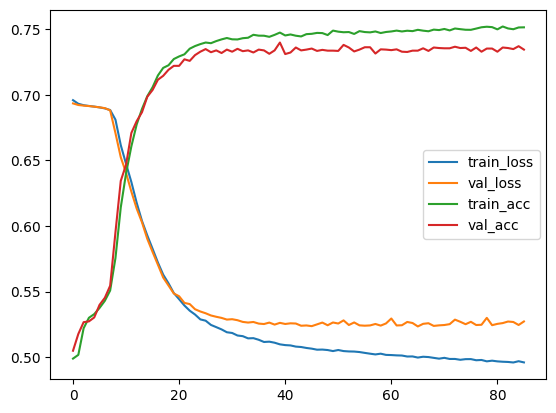

In [20]:
# 시각화
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'train_loss':train_losses,
    'val_loss':val_losses,
    'train_acc':train_accs,
    'val_acc':val_accs
})

df.plot()
plt.show()

In [21]:
# 평가
def evaluate_model(model, test_dataloader, criterion):
    model.eval()
    test_loss, test_correct,test_total = 0,0,0
    with torch.no_grad():
        for test_inputs,test_labels, in test_dataloader:
            output = model(test_inputs)
            loss = criterion(output,test_labels)

            test_loss += loss.item()
            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()
            test_correct += (pred == test_labels).sum().item()
            test_total += test_labels.size(0)

    test_loss = test_loss/len(test_dataloader)
    test_acc = test_correct/test_total

    return test_loss,test_acc

test_dataset = TensorDataset(X_test_onehot,y_test)
test_dataloader = DataLoader(test_dataset,batch_size=batch_size,shuffle=True)

test_loss, test_acc = evaluate_model(model, test_dataloader,criterion)
print(f'Test loss: {test_loss}, Test_acc: {test_acc}')

Test loss: 0.5272234765587339, Test_acc: 0.7311


## LSTM + Embedding

In [22]:
# LSTM 모델 생성
class LSTMSentimenticNet(nn.Module):
    def __init__(self,vocab_size, embedding_dim ,hidden_dim,output_dim):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim,output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, cell)= self.lstm(x)
        output = self.fc(hidden[-1])        # (num_layer, batch_size, hidden_size)
        return output 
    
embadding_dim = 50
hidden_size = 16
output_dim = 1

model=LSTMSentimenticNet(vocab_size,embadding_dim,hidden_size,output_dim)
model

LSTMSentimenticNet(
  (embedding): Embedding(300, 50, padding_idx=0)
  (lstm): LSTM(50, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [23]:
# 모델 파라미터 확인
total_params = 0
for name, param in model.named_parameters():
    # print(name,param)
    if param.requires_grad:             # 미분 가능한 파라미터만
        param_count = param.numel()     # 모든 가중치 개수
        total_params += param_count
        print(f'{name:<20} {str(list(param.shape)):<30} {param_count}')

print(f'Total Trainable Parameters : {total_params}')

embedding.weight     [300, 50]                      15000
lstm.weight_ih_l0    [64, 50]                       3200
lstm.weight_hh_l0    [64, 16]                       1024
lstm.bias_ih_l0      [64]                           64
lstm.bias_hh_l0      [64]                           64
fc.weight            [1, 16]                        16
fc.bias              [1]                            1
Total Trainable Parameters : 19369


## LSTM(num_layers) + Embedding

In [24]:
import torch
import torch.nn as nn

batch_size = 2
seq_len = 3
input_size = 4
hidden_size = 5

x = torch.randn(batch_size,seq_len,input_size)
print('X shape',x.shape)

lstm = nn.LSTM(input_size,hidden_size, batch_first=True,num_layers=2)
output, (hidden,cell) = lstm(x)

print('output: ',output.shape)
print('hidden: ',hidden.shape)      # (num_layer, batch_size, hidden_size)
print('cell: ',cell.shape)          # (num_layer, batch_size, hidden_size)

X shape torch.Size([2, 3, 4])
output:  torch.Size([2, 3, 5])
hidden:  torch.Size([2, 2, 5])
cell:  torch.Size([2, 2, 5])


In [25]:
# LSTM 모델 생성
class LSTMSentimenticNet(nn.Module):
    def __init__(self,vocab_size, embedding_dim ,hidden_dim,output_dim,num_layers):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            num_layers=num_layers
        )
        self.fc = nn.Linear(hidden_dim,output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, cell)= self.lstm(x)
        output = self.fc(hidden[-1])        # (num_layer, batch_size, hidden_size)
        return output 
    
embadding_dim = 50
hidden_size = 16
output_dim = 1

model=LSTMSentimenticNet(vocab_size,embadding_dim,hidden_size,output_dim,num_layers=2)
model

LSTMSentimenticNet(
  (embedding): Embedding(300, 50, padding_idx=0)
  (lstm): LSTM(50, 16, num_layers=2, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [26]:
# 모델 파라미터 확인
total_params = 0
for name, param in model.named_parameters():
    # print(name,param)
    if param.requires_grad:             # 미분 가능한 파라미터만
        param_count = param.numel()     # 모든 가중치 개수
        total_params += param_count
        print(f'{name:<20} {str(list(param.shape)):<30} {param_count}')

print(f'Total Trainable Parameters : {total_params}')

embedding.weight     [300, 50]                      15000
lstm.weight_ih_l0    [64, 50]                       3200
lstm.weight_hh_l0    [64, 16]                       1024
lstm.bias_ih_l0      [64]                           64
lstm.bias_hh_l0      [64]                           64
lstm.weight_ih_l1    [64, 16]                       1024
lstm.weight_hh_l1    [64, 16]                       1024
lstm.bias_ih_l1      [64]                           64
lstm.bias_hh_l1      [64]                           64
fc.weight            [1, 16]                        16
fc.bias              [1]                            1
Total Trainable Parameters : 21545


### Emebedding + LSTM(bidirectional)

![](https://d.pr/i/0u69xz+)


**Bidirectional LSTM**은 LSTM의 변형 모델로, **양방향으로 데이터를 처리**할 수 있도록 설계된 구조이다. 일반 LSTM이 입력 데이터를 **순방향(forward)** 으로만 처리하는 반면, Bidirectional LSTM은 **순방향**과 **역방향(backward)** 으로 데이터를 동시에 처리하여 더 많은 정보를 학습한다.


1. **양방향 정보 학습**  
   - 순방향 LSTM은 이전 시점의 정보만을 사용하여 다음 시점의 출력을 계산한다.
   - Bidirectional LSTM은 데이터의 시간적 흐름을 순방향과 역방향으로 모두 고려하여 **이전**과 **이후**의 정보를 동시에 학습한다.

2. **문맥 정보 강화**  
   - 예를 들어, 텍스트 데이터를 처리할 때 문장의 맥락(Context)을 양방향으로 학습하여 더 정확한 결과를 얻을 수 있다.  
    - 예: "He went to the bank ..."에서 "bank"가 "은행"인지 "강둑"인지 구분하기 위해 이후 단어의 정보를 활용할 수 있다.
    - Forward LSTM:
    ```He → went → to → the → bank → to → withdraw → money```
    - Backward LSTM:
    ```money → withdraw → to → bank → the → to → went → He```


In [27]:
import torch
import torch.nn as nn

batch_size = 2
seq_len = 3
input_size = 4
hidden_size = 5

x = torch.randn(batch_size,seq_len,input_size)
print('X shape',x.shape)

lstm = nn.LSTM(input_size,hidden_size, batch_first=True,num_layers=1,bidirectional=True)
output, (hidden,cell) = lstm(x)

print('output: ',output.shape)      # (batch_size, seq_len, hidden_size)
print('hidden: ',hidden.shape)      # (num_layer, batch_size, hidden_size)
print('cell: ',cell.shape)          # (num_layer, batch_size, hidden_size)

X shape torch.Size([2, 3, 4])
output:  torch.Size([2, 3, 10])
hidden:  torch.Size([2, 2, 5])
cell:  torch.Size([2, 2, 5])


In [28]:
# LSTM 모델 생성
class LSTMBiSentimenticNet(nn.Module):
    def __init__(self,vocab_size, embedding_dim ,hidden_dim,output_dim,num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            num_layers=num_layers,
            bidirectional=True
        )
        # 이전 LSTM 출력은 hidden_dim의 2배이다.
        self.fc = nn.Linear(hidden_dim*2,output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, cell)= self.lstm(x)
        forward_pass = hidden[-2]
        backward_pass = hidden[-1]

        # LSTM 순방향/역방향 결합
        hidden = torch.cat((forward_pass,backward_pass),dim=1)

        output = self.fc(hidden)
        return output

vocab_size = 300    
embadding_dim = 50
hidden_size = 16
output_dim = 1

model=LSTMBiSentimenticNet(vocab_size,embadding_dim,hidden_size,output_dim,num_layers=1)
model

LSTMBiSentimenticNet(
  (embedding): Embedding(300, 50, padding_idx=0)
  (lstm): LSTM(50, 16, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [29]:
# 모델 파라미터 확인
total_params = 0
for name, param in model.named_parameters():
    # print(name,param)
    if param.requires_grad:             # 미분 가능한 파라미터만
        param_count = param.numel()     # 모든 가중치 개수
        total_params += param_count
        print(f'{name:<20} {str(list(param.shape)):<30} {param_count}')

print(f'Total Trainable Parameters : {total_params}')

embedding.weight     [300, 50]                      15000
lstm.weight_ih_l0    [64, 50]                       3200
lstm.weight_hh_l0    [64, 16]                       1024
lstm.bias_ih_l0      [64]                           64
lstm.bias_hh_l0      [64]                           64
lstm.weight_ih_l0_reverse [64, 50]                       3200
lstm.weight_hh_l0_reverse [64, 16]                       1024
lstm.bias_ih_l0_reverse [64]                           64
lstm.bias_hh_l0_reverse [64]                           64
fc.weight            [1, 32]                        32
fc.bias              [1]                            1
Total Trainable Parameters : 23737


In [30]:
# one-hot encoding에서 Embedding으로 변경하여 입력 데이터 가공
X_train = torch.tensor(X_train,dtype=torch.long)
X_test = torch.tensor(X_test,dtype=torch.long)

y_train = torch.tensor(y_train,dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test,dtype=torch.float32).view(-1,1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([25000, 100]) torch.Size([25000, 1])
torch.Size([10000, 100]) torch.Size([10000, 1])


C:\Users\Playdata\AppData\Local\Temp\ipykernel_2196\394734944.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train,dtype=torch.float32).view(-1,1)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_2196\394734944.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test,dtype=torch.float32).view(-1,1)


In [31]:
# 학습/검증/평가 데이터 준비
from torch.utils.data import random_split,DataLoader,TensorDataset

batch_size = 64
train_size = int(len(X_train) * 0.8)
val_size = len(X_train) - train_size

train_dataset, val_dataset = random_split(TensorDataset(X_train,y_train),[train_size,val_size])
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_dataloader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [32]:
from torch.optim import Adam

# 손실 함수
criterion = nn.BCEWithLogitsLoss()
# 옵티마이저
optimizer = Adam(model.parameters(),lr=0.0001)

epochs = 100

# 시각화를 위한 기록
train_losses, val_losses, train_accs, val_accs = [],[],[],[]

# 조기 종료 관련
early_stopping_paitience = 20
best_val_loss = float('inf')
early_stopping_counter = 0

for epoch in range(epochs):
    total_loss, correct, total = 0,0,0

    # 학습
    model.train()
    for inputs, labels in train_dataloader:
        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output,labels)
        loss.backward()
        optimizer.step()

        # 배치 로그
        total_loss += loss.item()
        prob = torch.sigmoid(output)
        pred = (prob >= 0.5).float()
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    # 에폭 로그
    train_loss = total_loss/len(train_dataloader)
    train_losses.append(train_loss)
    train_acc = correct/total
    train_accs.append(train_acc)

    # 검증
    model.eval()
    val_loss, val_correct, val_total = 0,0,0
    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:
            
            output = model(val_inputs)
            loss = criterion(output, val_labels)
            
            # 배치 로그
            val_loss += loss.item()
            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()
            val_correct += (pred == val_labels).sum().item()
            val_total += val_labels.size(0)

        # 에폭 로그
        val_loss = val_loss/len(val_dataloader)
        val_losses.append(val_loss)
        val_acc = val_correct/val_total
        val_accs.append(val_acc)

        print(f'Epoch {epoch+1}/{epochs}: Train Loss : {train_loss:4f}\
              Train acc : {train_acc:4f} Val_loss : {val_loss:4f} Val_acc : {val_acc:4f}')
        
        # 조기 종료
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1
            if early_stopping_counter >= early_stopping_paitience:
                print(f'Early stopped at epoch {epoch + 1}') 
                break

Epoch 1/100: Train Loss : 0.694950              Train acc : 0.499550 Val_loss : 0.693835 Val_acc : 0.495600
Epoch 2/100: Train Loss : 0.692813              Train acc : 0.510300 Val_loss : 0.692806 Val_acc : 0.504400
Epoch 3/100: Train Loss : 0.691554              Train acc : 0.526150 Val_loss : 0.692099 Val_acc : 0.518400
Epoch 4/100: Train Loss : 0.690162              Train acc : 0.536150 Val_loss : 0.690371 Val_acc : 0.524000
Epoch 5/100: Train Loss : 0.688313              Train acc : 0.546500 Val_loss : 0.688899 Val_acc : 0.540200
Epoch 6/100: Train Loss : 0.685790              Train acc : 0.557750 Val_loss : 0.686495 Val_acc : 0.549000
Epoch 7/100: Train Loss : 0.682405              Train acc : 0.563650 Val_loss : 0.684028 Val_acc : 0.557200
Epoch 8/100: Train Loss : 0.678086              Train acc : 0.577000 Val_loss : 0.680659 Val_acc : 0.562600
Epoch 9/100: Train Loss : 0.673387              Train acc : 0.584800 Val_loss : 0.677690 Val_acc : 0.571000
Epoch 10/100: Train Loss : 0

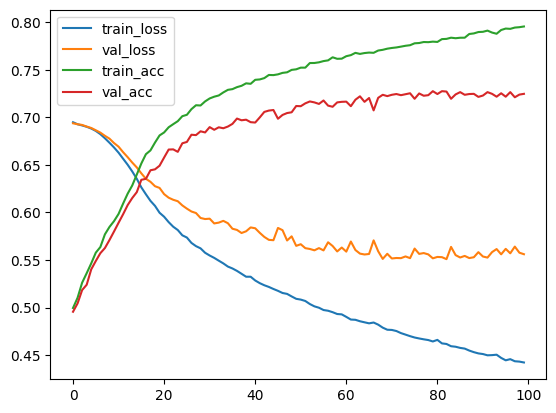

In [33]:
# 시각화
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'train_loss':train_losses,
    'val_loss':val_losses,
    'train_acc':train_accs,
    'val_acc':val_accs
})

df.plot()
plt.show()

In [35]:
# 평가
def evaluate_model(model, test_dataloader, criterion):
    model.eval()
    test_loss, test_correct,test_total = 0,0,0
    with torch.no_grad():
        for test_inputs,test_labels, in test_dataloader:
            output = model(test_inputs)
            loss = criterion(output,test_labels)

            test_loss += loss.item()
            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()
            test_correct += (pred == test_labels).sum().item()
            test_total += test_labels.size(0)

    test_loss = test_loss/len(test_dataloader)
    test_acc = test_correct/test_total

    return test_loss,test_acc

test_dataset = TensorDataset(X_test,y_test)
test_dataloader = DataLoader(test_dataset,batch_size=batch_size,shuffle=True)

test_loss, test_acc = evaluate_model(model, test_dataloader,criterion)
print(f'Test loss: {test_loss}, Test_acc: {test_acc}')

Test loss: 0.5707068500245452, Test_acc: 0.7225
